<a href="https://colab.research.google.com/github/hardik-zone/MyAnatomy/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ab_data = pd.read_csv("ab_data.csv")
countries = pd.read_csv("countries.csv")

In [4]:
print(ab_data.head())
print(countries.head())

   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1
   user_id country
0   834778      UK
1   928468      US
2   822059      UK
3   711597      UK
4   710616      UK


In [5]:
print(ab_data.columns)
print(countries.columns)

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='object')
Index(['user_id', 'country'], dtype='object')


In [6]:
ab_data = ab_data.drop_duplicates(subset="user_id")

countries = countries.drop_duplicates(subset="user_id")

In [7]:
print("AB data shape:", ab_data.shape)
print("Countries shape:", countries.shape)

AB data shape: (290584, 5)
Countries shape: (290584, 2)


In [9]:
df = pd.merge(
    ab_data,
    countries,
    on="user_id",
    how="inner"
)

In [10]:
df.head()


,user_id,timestamp,group,landing_page,converted,country
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,US
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,US
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,US
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,US
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,US


In [11]:
print(df.columns)

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted',
       'country'],
      dtype='object')


In [12]:
print(df.groupby("group")["converted"].mean())

group
control      0.120297
treatment    0.118843
Name: converted, dtype: float64


In [13]:
conversion_rate = df.groupby("group")["converted"].mean() * 100

print(conversion_rate)

group
control      12.029718
treatment    11.884253
Name: converted, dtype: float64


In [14]:
control = df[df["group"] == "control"]["converted"]

treatment = df[df["group"] == "treatment"]["converted"]

In [15]:
t_stat, p_value = ttest_ind(
    control,
    treatment,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.2083809283719142
P-value: 0.22690175562316608


In [16]:
alpha = 0.05

In [17]:
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference between control and treatment.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference between control and treatment.")

Fail to reject the null hypothesis.
There is no statistically significant difference between control and treatment.


In [18]:
us = df[df["country"] == "US"]["converted"]

uk = df[df["country"] == "UK"]["converted"]

ca = df[df["country"] == "CA"]["converted"]

In [19]:
f_stat, p_value = f_oneway(us, uk, ca)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.3329358528040876
P-value: 0.2637035460170248


In [20]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a significant difference in conversion among countries.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no significant difference in conversion among countries.")

Fail to reject the null hypothesis.
There is no significant difference in conversion among countries.


In [21]:
contingency_table = pd.crosstab(
    df["group"],
    df["converted"]
)

print(contingency_table)

converted       0      1
group                   
control    127761  17471
treatment  128078  17274


In [22]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1.446408325649827
P-value: 0.22910514252060252
Degrees of freedom: 1


In [23]:
print("Expected frequencies:")
print(expected)

Expected frequencies:
[[127866.67417339  17365.32582661]
 [127972.32582661  17379.67417339]]


In [24]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a significant association between group and conversion.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no significant association between group and conversion.")

Fail to reject the null hypothesis.
There is no significant association between group and conversion.


In [25]:
country_table = pd.crosstab(
    df["country"],
    df["converted"]
)

print(country_table)

converted       0      1
country                 
CA          12821   1678
UK          63732   8734
US         179286  24333


In [26]:
chi2, p_value, dof, expected = chi2_contingency(country_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 2.665874770967187
P-value: 0.26370152950116965
Degrees of freedom: 2


In [27]:
if p_value < 0.05:
    print("There is a significant association between country and conversion.")
else:
    print("There is no significant association between country and conversion.")

There is no significant association between country and conversion.


In [28]:
country_conversion = (
    df.groupby("country")["converted"]
    .agg(["count", "sum", "mean"])
)

country_conversion["conversion_rate_%"] = (
    country_conversion["mean"] * 100
)

print(country_conversion)

          count    sum      mean  conversion_rate_%
country                                            
CA        14499   1678  0.115732          11.573212
UK        72466   8734  0.120525          12.052549
US       203619  24333  0.119503          11.950260


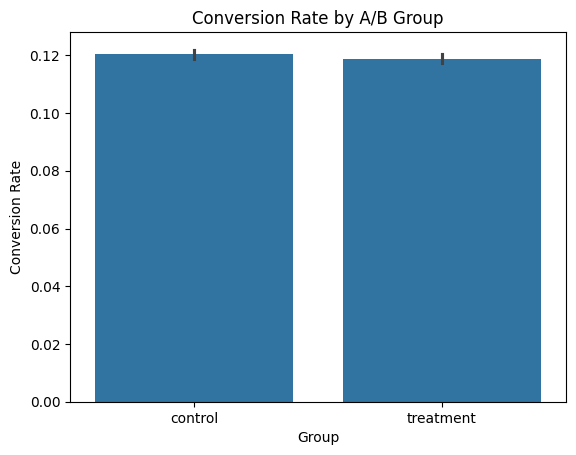

In [29]:
sns.barplot(
    data=df,
    x="group",
    y="converted"
)

plt.title("Conversion Rate by A/B Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.show()

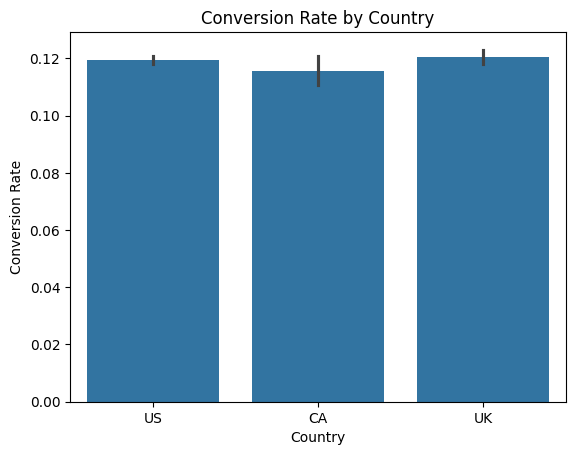

In [30]:
sns.barplot(
    data=df,
    x="country",
    y="converted"
)

plt.title("Conversion Rate by Country")
plt.ylabel("Conversion Rate")
plt.xlabel("Country")
plt.show()